## Statistical Validation Using Distributions, Variance & Effect Size

### Problem Statement

The progression analysis identified three student trajectories and two cliff groups based on counts and percentages alone. But descriptive statistics like means and modes are incomplete — they hide the shape, spread, and significance of differences between groups. Using histograms, outlier detection, variance, and effect size, we will determine which findings from the progression analysis are genuinely meaningful and which are too weak to act on. The goal is to move from observation to evidence.


### Goals

- Visualize the distribution shape of G1, G2, and G3 across the full dataset to understand how scores are naturally spread
- Visualize G3 distributions separately per progression label to see how Underachievers, On Track, and Overachievers differ visually
- Formally detect and document outliers in absences and deviation using the IQR method
- Compare the full G3 distribution between Above cliff and Below cliff groups beyond just median
- Calculate variance and standard deviation of G3 within each performance group to measure consistency
- Calculate Cohen's d effect size between Underachievers and Overachievers on absences and failures to determine if the unexpected Step 7 finding is meaningful
- Summarize all findings into a clean report that distinguishes strong evidence from weak signals


### Success Metrics

- Histograms reveal at least one non-obvious distribution shape such as skew, bimodal pattern, or unexpected clustering
- IQR method formally confirms the -11 deviation crash and +12 miracle recovery as statistical outliers
- At least one performance group shows significantly higher variance than others — identifying which group is most unpredictable
- Cohen's d on absences between Underachievers and Overachievers produces a result that either confirms or formally challenges the unexpected finding from Step 7
- The final report clearly separates findings into strong evidence and weak signals with justification for each


**Step 1 — Histograms of G1, G2, G3 (Full Dataset)**

Plot three separate histograms — one for each grade period. You want to see the shape of each distribution and whether it changes across periods.

**Step 2 — Histograms of G3 Per Progression Label**

Plot three histograms of G3 — one for Underachievers, one for On Track, one for Overachievers. You want to see whether each label has a distinct score distribution.

**Step 3 — Outlier Detection on Absences**

Formally identify which students have statistically abnormal absence counts using the IQR method.

**Step 4 — Outlier Detection on Deviation**

Apply the exact same IQR method to the deviation column in all_G_df.

**Step 5 — Compare G3 Distributions Above vs Below Cliff**

Go beyond median — look at the full spread of G3 scores for Above and Below cliff groups side by side.

**Step 6 — Variance and Standard Deviation Per Performance Group**

Which performance group is the most unpredictable? High variance means scores are all over the place within that group.

**Step 7 — Effect Size Using Cohen's d**

Your Step 7 finding was unexpected — Overachievers had MORE absences than Underachievers. Cohen's d will tell you if that difference is meaningful or just noise.

**Step 8 — Report Results**

### Libraries & Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import utils

# Load the raw data
df_full_math = pd.read_csv("student-mat.csv", sep=";")

# Add the IDs and Move Column (using your custom utils)
df_full_math = utils.add_unique_student_id(df_full_math, 'student_id', 'std')
df_full_math = utils.move_std_id(df_full_math, 'student_id')

# Re-create the progression labels logic so you have the groups to analyze
df_full_math['d'] = df_full_math['G2'] - df_full_math['G1']
df_full_math['expected_G3'] = (df_full_math['G2'] + df_full_math['d']).clip(0, 20)
df_full_math['deviation'] = df_full_math['G3'] - df_full_math['expected_G3']

def get_label(value):
    if value < 0: return "Underachiever"
    elif value == 0: return "On Track"
    else: return "Overachiever"

df_full_math['progression_label'] = df_full_math['deviation'].apply(get_label)

# Create the performance groups including the 0s
bins = [-1, 6, 9, 14, 20]
labels = ['Critical', 'At-risk', 'Passing', 'Strong']
df_full_math['performance_group'] = pd.cut(df_full_math['G3'], bins=bins, labels=labels)

In [2]:
df_full_math

,student_id,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,...,health,absences,G1,G2,G3,d,expected_G3,deviation,progression_label,performance_group
0,std001,GP,F,18,U,GT3,A,4,4,at_home,...,3,6,5,6,6,1,7,-1,Underachiever,Critical
1,std002,GP,F,17,U,GT3,T,1,1,at_home,...,3,4,5,5,6,0,5,1,Overachiever,Critical
2,std003,GP,F,15,U,LE3,T,1,1,at_home,...,3,10,7,8,10,1,9,1,Overachiever,Passing
3,std004,GP,F,15,U,GT3,T,4,2,health,...,5,2,15,14,15,-1,13,2,Overachiever,Strong
4,std005,GP,F,16,U,GT3,T,3,3,other,...,5,4,6,10,10,4,14,-4,Underachiever,Passing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,std391,MS,M,20,U,LE3,A,2,2,services,...,4,11,9,9,9,0,9,0,On Track,At-risk
391,std392,MS,M,17,U,LE3,T,3,1,services,...,2,3,14,16,16,2,18,-2,Underachiever,Strong
392,std393,MS,M,21,R,GT3,T,1,1,other,...,3,3,10,8,7,-2,6,1,Overachiever,At-risk
393,std394,MS,M,18,R,LE3,T,3,2,services,...,5,0,11,12,10,1,13,-3,Underachiever,Passing


### Step 1 — Histograms of G1, G2, G3

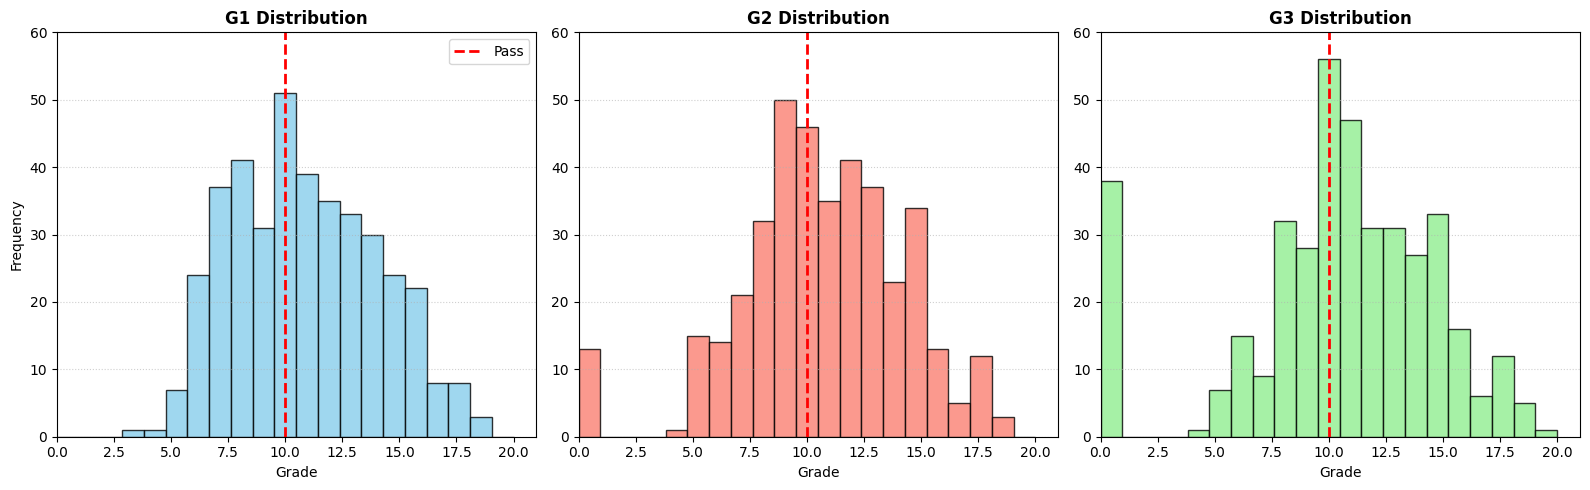

In [5]:
# Use a professional style
plt.style.use('seaborn-v0_8-muted') # or 'ggplot'

plt.figure(figsize=(16, 5)) # Slightly wider for breathing room

# Loop through the grades to keep code DRY (Don't Repeat Yourself)
grades = [('G1', 'skyblue'), ('G2', 'salmon'), ('G3', 'lightgreen')]

for i, (col, color) in enumerate(grades, 1):
    plt.subplot(1, 3, i)
    
    # Using bins=21 to perfectly align with 0-20 scale
    plt.hist(df_full_math[col], bins=21, range=(0, 20), 
             color=color, edgecolor='black', alpha=0.8)
    
    plt.axvline(10, color='red', linestyle='--', linewidth=2, label='Pass' if i==1 else "")
    
    # Unified scaling is the secret to neatness
    plt.xlim(0, 21) 
    plt.ylim(0, 60) # Keeps the "mountain" height consistent across all three
    
    plt.title(f'{col} Distribution', fontweight='bold')
    plt.xlabel('Grade')
    if i == 1: plt.ylabel('Frequency')
    if i == 1: plt.legend()
    plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Histogram Interpretation

#### 1. The Emergence of the "Zero-Cliff"
* **G1:** The distribution is roughly **"Normal"** (bell-shaped). Almost everyone is clustered between 7 and 15. There are **zero** students at the 0 mark.
* **G2:** A small "leak" begins. You see a tiny bar appearing at 0.
* **G3:** The "Cliff" is fully formed. There is a massive, isolated spike of nearly 40 students at **0**. This suggests that the final exam didn't just cause lower grades; it caused a total collapse for a specific segment of the class.

#### 2. The Flattening of the Curve (Variance)
* Notice how the "mountain" in **G1** is tall and skinny.
* By **G3**, the main mountain is shorter and wider.
* **The Insight:** This visually represents **increasing variance**. As the year progresses, students are spreading out—the strong are getting stronger, and the struggling are falling further behind. The class is becoming less "average" and more polarized.

#### 3. The Passing Threshold Shift
* In **G1**, the bulk of the "mountain" is to the right of the red dashed line.
* In **G3**, while the peak is still around 10-11, the "tail" on the left (the failing side) has grown significantly heavier.


### Step 2 — Histograms of G3 Per Progression Label

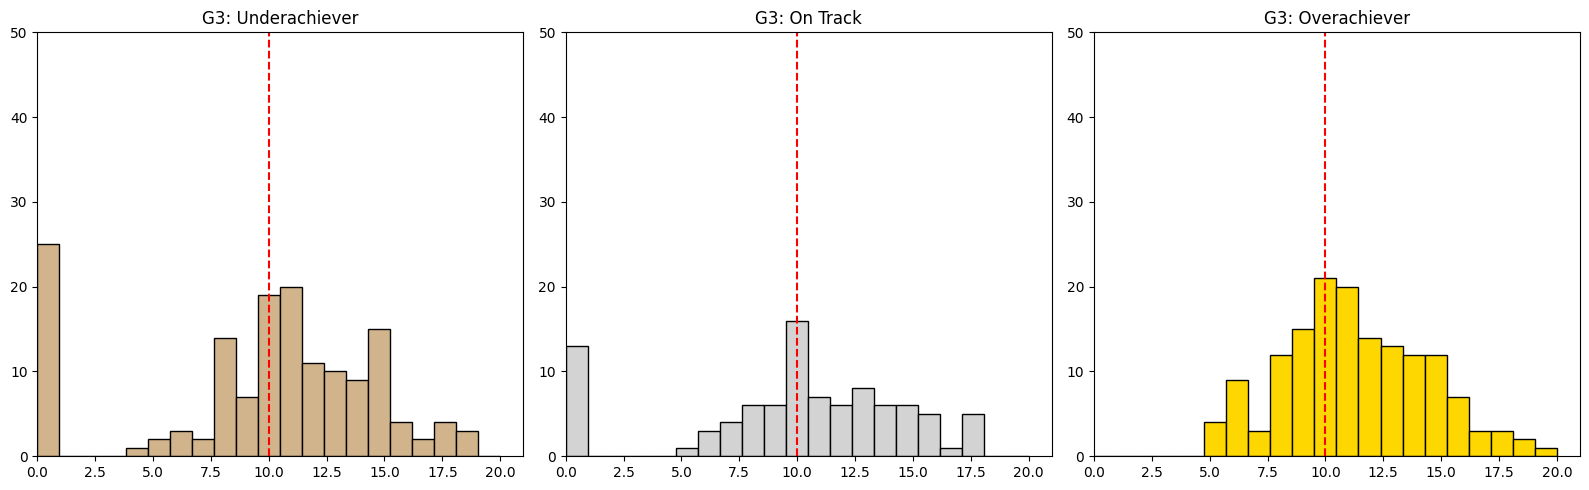

In [6]:
# Filter the data for each label
under = df_full_math[df_full_math['progression_label'] == 'Underachiever']
ontrack = df_full_math[df_full_math['progression_label'] == 'On Track']
over = df_full_math[df_full_math['progression_label'] == 'Overachiever']

plt.figure(figsize=(16, 5))

labels_data = [(under, 'Underachiever', 'tan'), 
               (ontrack, 'On Track', 'lightgrey'), 
               (over, 'Overachiever', 'gold')]

for i, (data, label, color) in enumerate(labels_data, 1):
    plt.subplot(1, 3, i)
    plt.hist(data['G3'], bins=21, range=(0, 20), color=color, edgecolor='black')
    plt.axvline(10, color='red', linestyle='--')
    plt.title(f'G3: {label}')
    plt.xlim(0, 21)
    plt.ylim(0, 50) # Keep scale consistent!

plt.tight_layout()
plt.show()

### Histogram Interpretation

#### 1. The Underachievers: The "Bimodal" Split
Notice how this group has two distinct peaks.
* **The Zero-Spike:** A huge portion of Underachievers didn't just "do worse"—they dropped to exactly **0**. These are likely the students who gave up or missed the final exam entirely.
* **The "Middling" Group:** The rest of the Underachievers are clustered right around the **10 (Passing)** mark.
* **The Insight:** Being an Underachiever in your model means falling behind your G1/G2 trajectory. This plot proves that for many, that "fall" was a total crash to zero.

#### 2. The On Track: The "Stable Middle"
* Most of these students are clustered tightly around **10-11**.
* **The Insight:** These students are predictable. Their G3 score is almost an exact reflection of their G1 and G2 performance. They represent the "Status Quo" of the class. They have a small spike at 0, but it is much smaller than the Underachievers.

#### 3. The Overachievers: The "Resilient Mountain"
This is the most interesting plot.
* **Zero Zeros:** Notice that the **0 bar is empty**. Not a single student who beat their trajectory ended up with a 0.
* **The Shift:** The entire "mountain" of students is shifted to the right of the red line. 
* **The Insight:** Overachievers are your "Success Stories." Even if they started with low grades (which made it easier to beat their trajectory), they all managed to show up and perform on the final.


### Step 3 & 4 — Outlier Detection on Absences and Deviation

In [7]:
def find_outliers_iqr(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# 1. Check Absences
abs_outliers, low_abs, high_abs = find_outliers_iqr(df_full_math, 'absences')
print(f"Absence Outliers: {len(abs_outliers)} (Anything above {high_abs})")

# 2. Check Deviation
dev_outliers, low_dev, high_dev = find_outliers_iqr(df_full_math, 'deviation')
print(f"Deviation Outliers: {len(dev_outliers)} (Lower than {low_dev} or Higher than {high_dev})")

Absence Outliers: 15 (Anything above 20.0)
Deviation Outliers: 23 (Lower than -4.0 or Higher than 4.0)


### Outlier Interpretation

| Feature | The "Normal" Zone | The Outlier Finding | Interpretation |
| :--- | :--- | :--- | :--- |
| **Absences** | 0 to 20 days | 15 students are outliers | Most "struggling" is done within 20 days. Anyone beyond that is an extreme case. |
| **Deviation** | -4 to +4 points | 23 students are outliers | The model is very accurate for 94% of students. The 23 outliers are the only ones who truly "broke" the trend. |
